# K-Means Baseline

This notebook creates the first K-Means clustering baseline for the customer segmentation project.

The goal is to test different numbers of clusters and compare simple evaluation metrics. This result is not necessarily the final clustering solution. The next phase will interpret and profile the clusters so the solution can be judged from a business perspective.

## Load Data

The modelling input is the selected feature table from the previous phase. It is already scaled, encoded, compact, and prepared for the first clustering baseline.

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

os.makedirs("outputs/clustering", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

df = pd.read_csv("../data/processed/selected_model_features.csv")
print(f"Loaded rows: {len(df):,}")
print(f"Loaded columns: {df.shape[1]}")

Loaded rows: 33,038
Loaded columns: 26


## Data Validation

Before modelling, the notebook checks that every customer appears once, that there are no missing values, and that all modelling columns are numeric.

In [4]:
if "customer_id" not in df.columns:
    raise ValueError("customer_id column is missing from the modelling input.")

row_count = len(df)
unique_customer_count = df["customer_id"].nunique()
duplicated_customer_count = df["customer_id"].duplicated().sum()
missing_value_count = df.isna().sum().sum()
modelling_preview = df.drop(columns=["customer_id"])
non_numeric_columns = modelling_preview.select_dtypes(exclude="number").columns.tolist()

print(f"Rows loaded: {row_count:,}")
print(f"Unique customer_id values: {unique_customer_count:,}")
print(f"Duplicated customer_id count: {duplicated_customer_count:,}")
print(f"Total missing values: {missing_value_count:,}")
print(f"Modelling columns are numeric: {len(non_numeric_columns) == 0}")

if duplicated_customer_count > 0:
    raise ValueError("Duplicated customer_id values found in the modelling input.")

if missing_value_count > 0:
    raise ValueError("Missing values found in the modelling input.")

if non_numeric_columns:
    raise ValueError(f"Non-numeric modelling columns found: {non_numeric_columns}")

Rows loaded: 33,038
Unique customer_id values: 33,038
Duplicated customer_id count: 0
Total missing values: 0
Modelling columns are numeric: True


## Prepare Modelling Data

The `customer_id` column is kept only for saving the final assignments. It is not used as a K-Means feature.

In [5]:
customer_ids = df["customer_id"]
X = df.drop(columns=["customer_id"])

print(f"Customers: {len(customer_ids):,}")
print(f"Model features: {X.shape[1]}")

Customers: 33,038
Model features: 25


## Test K-Means Solutions

The baseline tests cluster counts from 2 to 10. The silhouette score uses a sample of up to 10,000 rows for performance.

In [6]:
sample_size = min(10000, len(X))
metrics_rows = []

for k in range(2, 11):
    print(f"Fitting K-Means with k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(X)
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    metrics_rows.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(X, labels, sample_size=sample_size, random_state=42),
        "calinski_harabasz_score": calinski_harabasz_score(X, labels),
        "davies_bouldin_score": davies_bouldin_score(X, labels),
        "min_cluster_size": int(cluster_sizes.min()),
        "max_cluster_size": int(cluster_sizes.max()),
        "min_cluster_percentage": cluster_sizes.min() / len(X) * 100,
        "max_cluster_percentage": cluster_sizes.max() / len(X) * 100,
    })

metrics = pd.DataFrame(metrics_rows)
metrics.to_csv("outputs/clustering/kmeans_metrics.csv", index=False)

print("Saved metrics to outputs/clustering/kmeans_metrics.csv")
metrics

Fitting K-Means with k=2
Fitting K-Means with k=3
Fitting K-Means with k=4
Fitting K-Means with k=5
Fitting K-Means with k=6
Fitting K-Means with k=7
Fitting K-Means with k=8
Fitting K-Means with k=9
Fitting K-Means with k=10
Saved metrics to outputs/clustering/kmeans_metrics.csv


,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
0,2,606740.859778,0.212345,4542.982634,2.359428,7514,25524,22.743507,77.256493
1,3,554049.497925,0.133191,4058.291747,2.129160,5808,20664,17.579757,62.546159
2,4,511641.302405,0.124297,3842.379979,2.266195,4740,11201,14.347115,33.903384
3,5,478598.468556,0.135222,3650.808841,2.108630,2234,10841,6.761911,32.813730
4,6,455569.776126,0.127311,3402.138050,2.096260,2008,9816,6.077850,29.711242
5,7,436732.338757,0.112704,3194.767037,2.066140,1894,7818,5.732793,23.663660
6,8,418882.914448,0.121967,3056.038449,2.030153,1764,6028,5.339306,18.245657
7,9,404135.553860,0.125610,2922.186158,1.976776,1502,5583,4.546280,16.898723
8,10,392759.010600,0.130808,2778.954384,2.011943,1496,5355,4.528119,16.208608


## Evaluation Charts

These charts compare compactness, separation, and cluster balance across the tested values of `k`.

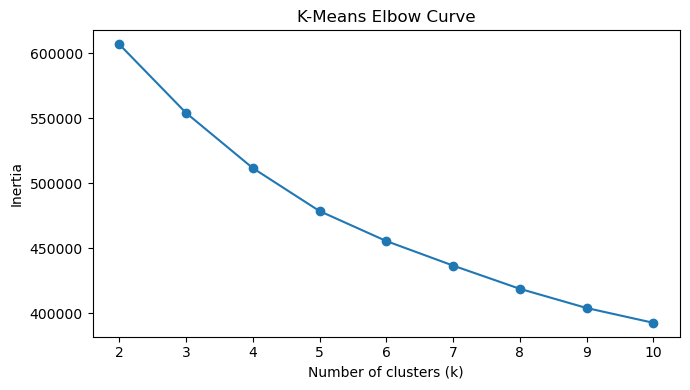

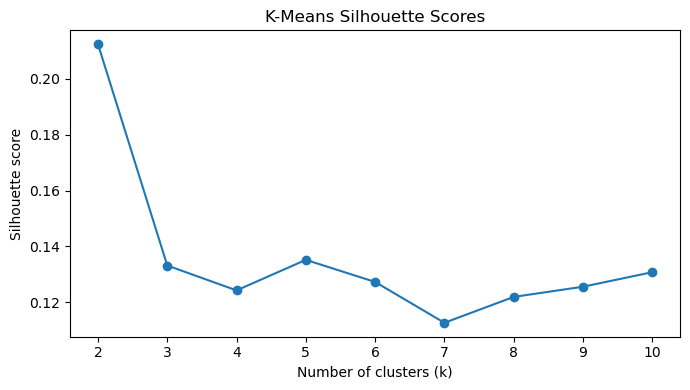

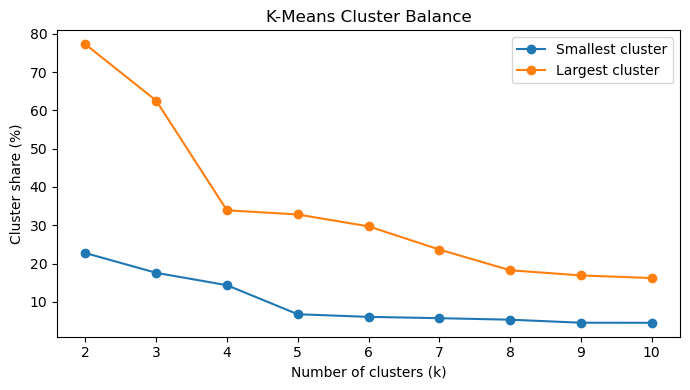

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.savefig("outputs/figures/kmeans_elbow.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Scores")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.savefig("outputs/figures/kmeans_silhouette.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["min_cluster_percentage"], marker="o", label="Smallest cluster")
plt.plot(metrics["k"], metrics["max_cluster_percentage"], marker="o", label="Largest cluster")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cluster share (%)")
plt.title("K-Means Cluster Balance")
plt.xticks(metrics["k"])
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/kmeans_cluster_balance.png", dpi=150)
plt.show()

## Initial k Choice

The initial baseline uses `k=5`.

`k=2` has the strongest silhouette score, but it places more than three quarters of customers into one cluster, so it is too broad for useful segmentation. `k=5` is a more balanced starting point: the elbow curve still shows meaningful improvement before the gains slow down, the silhouette score is the strongest option after `k=2`, the Davies-Bouldin score improves compared with `k=4`, and the cluster sizes remain interpretable. Higher values of `k` improve some metrics slightly but create a more fragmented solution for a first baseline.

In [8]:
SELECTED_K = 5
print(f"Selected k: {SELECTED_K}")

Selected k: 5


## Final Baseline Model

The final baseline model is fitted on the selected modelling features, not on PCA components. The saved output contains each customer and their assigned cluster.

In [9]:
final_kmeans = KMeans(n_clusters=SELECTED_K, random_state=42, n_init=50)
final_labels = final_kmeans.fit_predict(X)

cluster_assignments = pd.DataFrame({
    "customer_id": customer_ids,
    "cluster": final_labels,
})

cluster_assignments.to_csv("outputs/clustering/kmeans_customer_clusters.csv", index=False)

print("Saved cluster assignments to outputs/clustering/kmeans_customer_clusters.csv")
print(cluster_assignments.head())

Saved cluster assignments to outputs/clustering/kmeans_customer_clusters.csv
   customer_id  cluster
0            3        3
1            4        2
2            5        3
3            7        4
4            8        4


## PCA Visualization

PCA is used only for a two-dimensional visual inspection of the clusters. K-Means is not trained on the PCA components in this baseline.

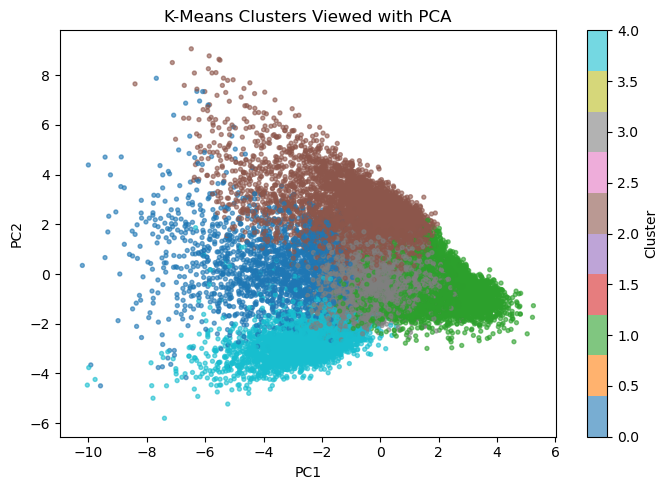

PCA explained variance ratio: [0.17950417 0.12414316]


In [10]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=final_labels,
    cmap="tab10",
    s=8,
    alpha=0.6,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters Viewed with PCA")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("outputs/figures/kmeans_pca_clusters.png", dpi=150)
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

## Final Validation

The final checks confirm that the saved cluster assignment file has one valid cluster label for every input customer.

In [11]:
saved_clusters = pd.read_csv("outputs/clustering/kmeans_customer_clusters.csv")
cluster_size_table = saved_clusters["cluster"].value_counts().sort_index()
row_count_matches = len(saved_clusters) == len(df)

print(f"Rows in kmeans_customer_clusters.csv: {len(saved_clusters):,}")
print(f"Unique customer_id values: {saved_clusters['customer_id'].nunique():,}")
print(f"Missing cluster values: {saved_clusters['cluster'].isna().sum():,}")
print("Cluster size table:")
print(cluster_size_table.to_string())
print(f"Output row count matches input row count: {row_count_matches}")

if not row_count_matches:
    raise ValueError("Cluster output row count does not match the input row count.")

if saved_clusters["customer_id"].duplicated().sum() > 0:
    raise ValueError("Cluster output contains duplicated customer_id values.")

if saved_clusters["cluster"].isna().sum() > 0:
    raise ValueError("Cluster output contains missing cluster values.")

Rows in kmeans_customer_clusters.csv: 33,038
Unique customer_id values: 33,038
Missing cluster values: 0
Cluster size table:
cluster
0     2234
1    10841
2     6687
3     9889
4     3387
Output row count matches input row count: True
